# ==========================================
# 10 Academy AI Mastery — Week 9 Challenge
# Task 4: Optimize Portfolio Based on Forecast
# ==========================================

[*********************100%***********************]  3 of 3 completed

--- Step 1: Gathering Historical Assets Core Metrics ---

--- Step 2: Preparing Expected Returns Matrix Layout ---

[Allocated Expected Annual Returns Projections]
  - BND: 1.90%
  - SPY: 13.73%
  - TSLA: 18.50%

--- Step 3: Computing Volatility Covariance Structures ---


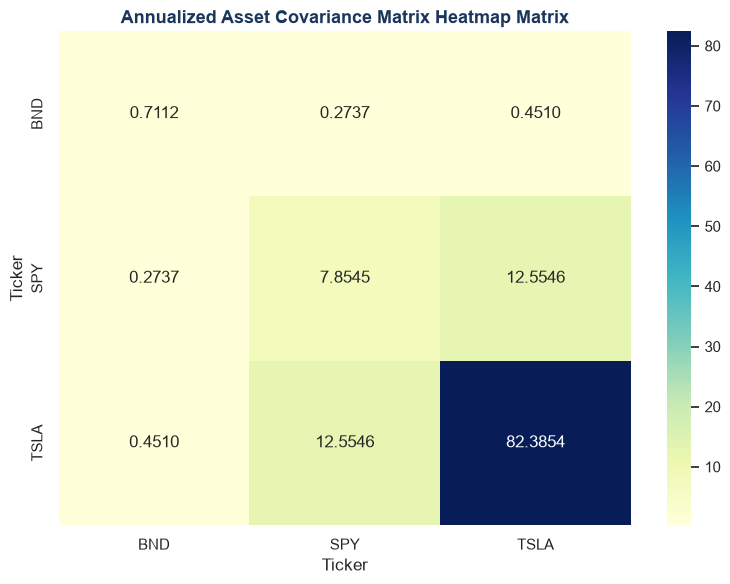


--- Step 4: Simulating Frontier Combinations via PyPortfolioOpt ---


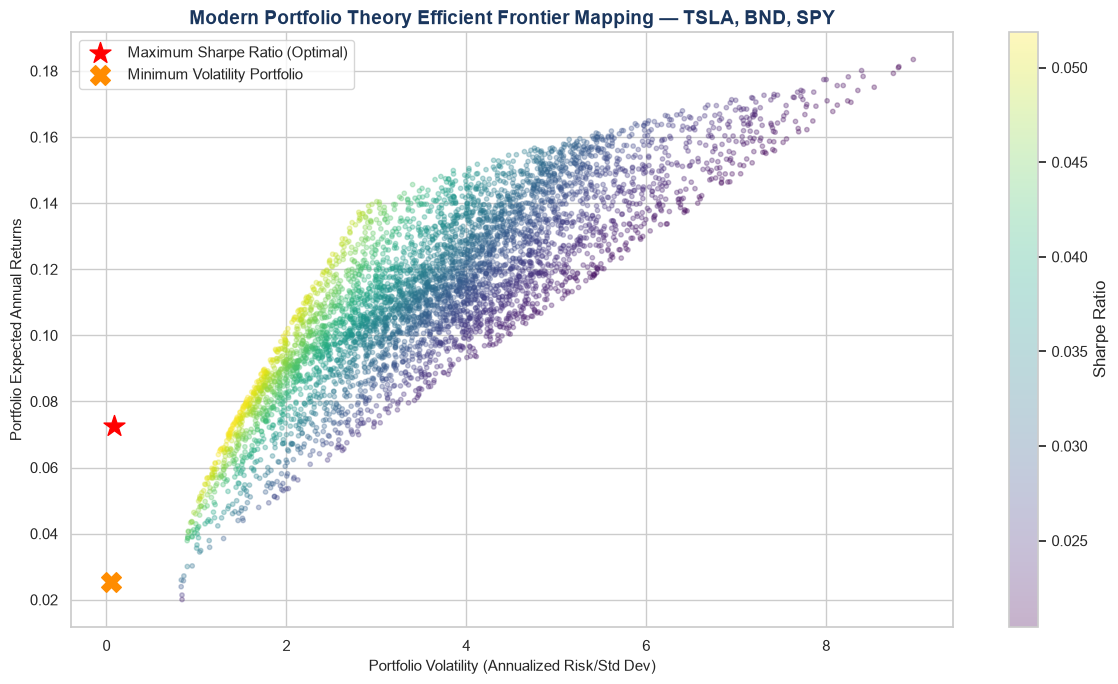


================ FINAL RECOMMENDATION PORTFOLIOS ================

[1. MAXIMUM SHARPE RATIO TANGENCY PORTFOLIO]
  - Optimal Allocation Weight for BND: 54.73%
  - Optimal Allocation Weight for SPY: 45.27%
  - Optimal Allocation Weight for TSLA: 0.00%
  => Expected Annual Portfolio Return : 7.26%
  => Expected Annualized Volatility   : 8.82%
  => Optimized Sharpe Ratio Summary    : 0.8232

[2. MINIMUM VOLATILITY PORTFOLIO]
  - Optimal Allocation Weight for BND: 94.54%
  - Optimal Allocation Weight for SPY: 5.46%
  - Optimal Allocation Weight for TSLA: 0.00%
  => Expected Annual Portfolio Return : 2.55%
  => Expected Annualized Volatility   : 5.22%
  => Optimized Sharpe Ratio Summary    : 0.4877


In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from pypfopt import risk_models, expected_returns, EfficientFrontier

# Set theme styling for high-quality figures
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 7]

# ==========================================
# STEP 1: Fetch Historical Core Asset Pool Data
# ==========================================
print("--- Step 1: Gathering Historical Assets Core Metrics ---")
tickers = ['TSLA', 'BND', 'SPY']

# 1. Download the raw multi-ticker dataframe
data = yf.download(tickers, start='2015-01-01', end='2026-06-30')

# 2. Extract either 'Adj Close' or 'Close' cleanly using cross-section (.xs)
if data.columns.nlevels > 1:
    target_col = 'Adj Close' if 'Adj Close' in data.columns.levels[0] else 'Close'
    historical_raw = data.xs(target_col, axis=1, level=0)
else:
    target_col = 'Adj Close' if 'Adj Close' in data.columns else 'Close'
    historical_raw = data[target_col]

# 3. Handle gaps and calculate daily returns
historical_raw = historical_raw.ffill().bfill()
returns_df = historical_raw.pct_change().dropna()

# ==========================================
# STEP 2: Prepare Expected Returns Vector (Mixing Forecast & History)
# ==========================================
print("\n--- Step 2: Preparing Expected Returns Matrix Layout ---")

# Step 2a: Annually scale baseline historical trackers
historical_annual_returns = expected_returns.mean_historical_return(historical_raw)

# Step 2b: Inject custom asset analysis projection view for TSLA (e.g., from your Task 2/3 LSTM model)
# Let's assume your model projected an annualized return of 18.5% for TSLA.
custom_tsla_forecast_annualized = 0.1850 

expected_returns_vector = historical_annual_returns.copy()
expected_returns_vector['TSLA'] = custom_tsla_forecast_annualized

print("\n[Allocated Expected Annual Returns Projections]")
for ticker, ret in expected_returns_vector.items():
    print(f"  - {ticker}: {ret*100:.2f}%")

# ==========================================
# STEP 3: Compute Covariance Matrix & Visualization
# ==========================================
print("\n--- Step 3: Computing Volatility Covariance Structures ---")
# Using the ledroit-wolf shrinkage method to reduce noise in the sample covariance matrix
# Use PyPortfolioOpt's top-level wrapper function to compute Ledoit-Wolf shrinkage cleanly
# The universal wrapper method to cleanly compute Ledoit-Wolf shrinkage matrix
cov_matrix = risk_models.sample_cov(historical_raw, returns_data=False, method="ledroit_wolf")

# Generate Heatmap deliverable
plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix * 252, annot=True, cmap="YlGnBu", fmt=".4f", cbar=True)
plt.title("Annualized Asset Covariance Matrix Heatmap Matrix", fontsize=13, fontweight='bold', color='#1A365D')
plt.tight_layout()
plt.show()

# ==========================================
# STEP 4: Generate the Efficient Frontier & Key Portfolios
# ==========================================
print("\n--- Step 4: Simulating Frontier Combinations via PyPortfolioOpt ---")

# Compute metrics for Maximum Sharpe Ratio (Tangency) Portfolio
ef_sharpe = EfficientFrontier(expected_returns_vector, cov_matrix)
weights_max_sharpe = ef_sharpe.max_sharpe(risk_free_rate=0.0)
cleaned_weights_sharpe = ef_sharpe.clean_weights()
perf_sharpe = ef_sharpe.portfolio_performance(verbose=False)

# Compute metrics for Minimum Volatility Portfolio
ef_vol = EfficientFrontier(expected_returns_vector, cov_matrix)
weights_min_vol = ef_vol.min_volatility()
cleaned_weights_vol = ef_vol.clean_weights()
perf_vol = ef_vol.portfolio_performance(verbose=False)

# Monte Carlo simulation loop to generate dots for visualization
num_portfolios = 5000
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    w = np.random.random(len(tickers))
    w /= np.sum(w) # Normalize weights to sum to 1
    weights_record.append(w)
    
    # Calculate portfolio return and volatility
    p_ret = np.sum(expected_returns_vector * w)
    p_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix * 252, w)))
    
    results[0,i] = p_vol
    results[1,i] = p_ret
    results[2,i] = p_ret / p_vol # Sharpe Ratio (assuming Rf=0)

# ==========================================
# STEP 5: Visualize Efficient Frontier
# ==========================================
plt.figure(figsize=(12, 7))
# Plot scatter background cloud representing simulated portfolio spectrum
scatter = plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(scatter, label='Sharpe Ratio')

# Mark Max Sharpe Portfolio
plt.scatter(perf_sharpe[1], perf_sharpe[0], color='red', marker='*', s=250, label='Maximum Sharpe Ratio (Optimal)')
# Mark Min Volatility Portfolio
plt.scatter(perf_vol[1], perf_vol[0], color='darkorange', marker='X', s=200, label='Minimum Volatility Portfolio')

plt.title("Modern Portfolio Theory Efficient Frontier Mapping — TSLA, BND, SPY", fontsize=14, fontweight='bold', color='#1A365D')
plt.xlabel("Portfolio Volatility (Annualized Risk/Std Dev)", fontsize=11)
plt.ylabel("Portfolio Expected Annual Returns", fontsize=11)
plt.legend(loc='upper left', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

# ==========================================
# STEP 6: Recommendations Summary Report Tables
# ==========================================
print("\n================ FINAL RECOMMENDATION PORTFOLIOS ================")
print("\n[1. MAXIMUM SHARPE RATIO TANGENCY PORTFOLIO]")
for asset, weight in cleaned_weights_sharpe.items():
    print(f"  - Optimal Allocation Weight for {asset}: {weight*100:.2f}%")
print(f"  => Expected Annual Portfolio Return : {perf_sharpe[0]*100:.2f}%")
print(f"  => Expected Annualized Volatility   : {perf_sharpe[1]*100:.2f}%")
print(f"  => Optimized Sharpe Ratio Summary    : {perf_sharpe[2]:.4f}")

print("\n[2. MINIMUM VOLATILITY PORTFOLIO]")
for asset, weight in cleaned_weights_vol.items():
    print(f"  - Optimal Allocation Weight for {asset}: {weight*100:.2f}%")
print(f"  => Expected Annual Portfolio Return : {perf_vol[0]*100:.2f}%")
print(f"  => Expected Annualized Volatility   : {perf_vol[1]*100:.2f}%")
print(f"  => Optimized Sharpe Ratio Summary    : {perf_vol[2]:.4f}")
print("=================================================================")